In [1]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Suppress warning messages during pipeline execution
warnings.filterwarnings('ignore')

print('====================================================================')
print('=== COMPONENT 2: PROCUREMENT & BUY ADVICE OPTIMIZATION ANALYTICS ===')
print('====================================================================\n')

=== COMPONENT 2: PROCUREMENT & BUY ADVICE OPTIMIZATION ANALYTICS ===



In [2]:
# =========================================================================
# STEP 1: DATA LOADING & PRELIMINARY CLEANING
# =========================================================================
try:
    df = pd.read_csv('from_rice_veg_2023_2026.csv')
    print("✅ Successfully loaded real dataset: from_rice_veg_2023_2026.csv")
except FileNotFoundError:
    print("⚠️ Dataset file not found! Generating realistic synthetic fallback dataset...")
    np.random.seed(42)
    n = 1000
    current_price = np.random.uniform(100, 500, n)
    trend = np.random.uniform(-0.1, 0.2, n)
    future_price = current_price * (1 + trend) + np.random.normal(0, 5, n)
    
    # Target buy logic for realistic synthetic data
    # (Buy if future price is expected to rise by more than LKR 10)
    target_buy = ((future_price - current_price) > 10).astype(int)

    df = pd.DataFrame({
        'item': np.random.choice(['Samba Rice', 'Carrot', 'Onion', 'Potato'], size=n),
        'current_price_rs': current_price,
        'historical_avg_price_rs': current_price * np.random.uniform(0.9, 1.1, n),
        'expected_retail_price_rs': current_price * np.random.uniform(1.15, 1.4, n),
        'price_trend_30d': trend,
        'price_std_30d': np.random.uniform(5, 30, n),
        'current_stock_kg': np.random.uniform(10, 500, n),
        'shelf_life_days': np.random.choice([3, 7, 14, 30, 90], size=n),
        'target_buy_now': target_buy,
        'expected_price_next_4wk_rs': future_price
    })

# Remove duplicate records to prevent data leakage
df = df.drop_duplicates().reset_index(drop=True)
df = df.drop(columns=['item_id', 'date'], errors='ignore')


✅ Successfully loaded real dataset: from_rice_veg_2023_2026.csv


In [3]:
# =========================================================================
# STEP 2: DOMAIN FEATURE ENGINEERING
# =========================================================================
print("\n=== Generating Domain-Specific Engineered Features ===")
if 'current_price_rs' in df.columns and 'historical_avg_price_rs' in df.columns:
    df['price_variance_pct'] = ((df['current_price_rs'] - df['historical_avg_price_rs']) / (df['historical_avg_price_rs'] + 1e-5)) * 100

if 'expected_retail_price_rs' in df.columns and 'current_price_rs' in df.columns:
    df['expected_profit_margin'] = ((df['expected_retail_price_rs'] - df['current_price_rs']) / (df['current_price_rs'] + 1e-5)) * 100

if 'price_trend_30d' in df.columns and 'current_price_rs' in df.columns:
    df['price_momentum'] = df['price_trend_30d'] * df['current_price_rs']

if 'price_std_30d' in df.columns and 'historical_avg_price_rs' in df.columns:
    df['price_volatility_index'] = df['price_std_30d'] / (df['historical_avg_price_rs'] + 1e-5)



=== Generating Domain-Specific Engineered Features ===


In [4]:
# =========================================================================
# STEP 3: TARGET & FEATURE SEPARATION
# =========================================================================
X = df.drop(columns=['target_buy_now', 'expected_price_next_4wk_rs'], errors='ignore')
y_cls = df['target_buy_now'].astype(int)
y_reg = df['expected_price_next_4wk_rs'].astype(float) if 'expected_price_next_4wk_rs' in df.columns else df['current_price_rs'] * 1.05

cat_cols = ['item', 'category'] if 'item' in X.columns else X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ]
)

X_train, X_test, y_train_cls, y_test_cls, y_train_reg, y_test_reg = train_test_split(
    X, y_cls, y_reg, test_size=0.20, random_state=42, stratify=y_cls
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [5]:
# =========================================================================
# STEP 4: MODEL PIPELINES & BENCHMARKING
# =========================================================================
models = {
    'LogisticRegression': Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))]),
    'DecisionTree': Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, class_weight='balanced', random_state=42))]),
    'RandomForest': Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1))]),
    'GradientBoosting': Pipeline([('prep', preprocessor), ('clf', GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, max_depth=4, subsample=0.85, random_state=42))]),
}

try:
    from xgboost import XGBClassifier
    models['XGBoost'] = Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, eval_metric='logloss', random_state=42, n_jobs=-1))
    ])
except ImportError:
    print('Notice: XGBoost not installed. Running with Sklearn Models.')

print('\n=== Running 5-Fold Cross Validation Benchmarking ===')
cv_results = {}
for name, m in models.items():
    scores = cross_validate(m, X_train, y_train_cls, cv=cv, scoring=['roc_auc', 'accuracy', 'f1'], n_jobs=-1)
    cv_results[name] = {'auc': scores['test_roc_auc'].mean(), 'acc': scores['test_accuracy'].mean(), 'f1': scores['test_f1'].mean()}
    print(f'  {name:20s} | CV ROC-AUC: {cv_results[name]["auc"]:.3f} | CV Acc: {cv_results[name]["acc"]:.3f} | CV F1: {cv_results[name]["f1"]:.3f}')

best_model_name = max(cv_results, key=lambda k: cv_results[k]['auc'])
print(f'\n🏆 Champion Classification Model: {best_model_name}')

champion_cls_model = models[best_model_name]
champion_cls_model.fit(X_train, y_train_cls)

# Test Set Evaluation
y_pred_cls = champion_cls_model.predict(X_test)
y_pred_proba = champion_cls_model.predict_proba(X_test)[:, 1]
print("\n--- Champion Classification Model Test Evaluation ---")
print(f"Test ROC-AUC : {roc_auc_score(y_test_cls, y_pred_proba):.3f}")
print(f"Test Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.3f}")
print(f"Test F1 Score: {f1_score(y_test_cls, y_pred_cls):.3f}")



=== Running 5-Fold Cross Validation Benchmarking ===
  LogisticRegression   | CV ROC-AUC: 0.773 | CV Acc: 0.700 | CV F1: 0.714
  DecisionTree         | CV ROC-AUC: 0.787 | CV Acc: 0.729 | CV F1: 0.731
  RandomForest         | CV ROC-AUC: 0.798 | CV Acc: 0.736 | CV F1: 0.735
  GradientBoosting     | CV ROC-AUC: 0.806 | CV Acc: 0.736 | CV F1: 0.737
  XGBoost              | CV ROC-AUC: 0.810 | CV Acc: 0.736 | CV F1: 0.738

🏆 Champion Classification Model: XGBoost

--- Champion Classification Model Test Evaluation ---
Test ROC-AUC : 0.815
Test Accuracy: 0.737
Test F1 Score: 0.737


In [6]:
# =========================================================================
# STEP 5: REGRESSION MODEL TRAINING (PRICE FORECASTING)
# =========================================================================
print('\n=== Training Price Forecasting Engine (Regression) ===')
price_regressor = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1))
])
price_regressor.fit(X_train, y_train_reg)

y_reg_pred = price_regressor.predict(X_test)
print(f'Price Forecast MAE : LKR {mean_absolute_error(y_test_reg, y_reg_pred):,.2f}')
print(f'Price Forecast R2  : {r2_score(y_test_reg, y_reg_pred):.3f}')



=== Training Price Forecasting Engine (Regression) ===
Price Forecast MAE : LKR 10.43
Price Forecast R2  : 0.991


In [7]:
# =========================================================================
# STEP 6: HYBRID RULE ENGINE & RECOMMENDATION WRAPPER
# =========================================================================
def evaluate_procurement_recommendation(row_df, cls_pipeline, reg_pipeline):
    """
    Combines Machine Learning Predictions with Hard Business Rules 
    to make final procurement recommendations.
    """
    # ML Model Probability & Regression Price Forecast
    cls_proba = cls_pipeline.predict_proba(row_df)[0, 1]
    predicted_future_price = reg_pipeline.predict(row_df)[0]
    current_price = row_df['current_price_rs'].values[0]
    stock = row_df['current_stock_kg'].values[0] if 'current_stock_kg' in row_df.columns else 0
    shelf_life = row_df['shelf_life_days'].values[0] if 'shelf_life_days' in row_df.columns else 30

    recommendation = "HOLD / DO NOT BUY"
    reasoning = []

    # Rule 1: High stock overload check
    if stock > 400:
        recommendation = "HOLD / DO NOT BUY"
        reasoning.append(f"Overstock Risk: Current stock ({stock}kg) exceeds maximum limit (400kg).")
    # Rule 2: Perishable goods quick turnover check
    elif shelf_life <= 3 and stock > 50:
        recommendation = "HOLD / DO NOT BUY"
        reasoning.append(f"Perishability Risk: Shelf life is low ({shelf_life} days) and current stock is high ({stock}kg).")
    # Rule 3: High Confidence ML Buy Signal
    elif cls_proba >= 0.70:
        recommendation = "BULK BUY NOW"
        reasoning.append(f"High AI Confidence ({cls_proba*100:.1f}%). Expected price rise to LKR {predicted_future_price:.2f}.")
    # Rule 4: Moderate Confidence ML Buy Signal
    elif cls_proba >= 0.50:
        recommendation = "MODERATE BUY"
        reasoning.append(f"Moderate AI Confidence ({cls_proba*100:.1f}%). Monitor market conditions closely.")
    else:
        recommendation = "HOLD / DO NOT BUY"
        reasoning.append(f"Low AI Recommendation Confidence ({cls_proba*100:.1f}%). Price is expected to drop or remain stable.")

    return {
        'recommendation': recommendation,
        'ai_confidence_pct': round(cls_proba * 100, 2),
        'predicted_future_price_rs': round(predicted_future_price, 2),
        'price_difference_rs': round(predicted_future_price - current_price, 2),
        'reasoning': " | ".join(reasoning)
    }

# Test sample evaluation using rule engine
sample_record = X_test.iloc[[0]]
sample_result = evaluate_procurement_recommendation(sample_record, champion_cls_model, price_regressor)
print("\n=== Sample Recommendation Output ===")
for k, v in sample_result.items():
    print(f"  {k:27s}: {v}")



=== Sample Recommendation Output ===
  recommendation             : BULK BUY NOW
  ai_confidence_pct          : 86.86000061035156
  predicted_future_price_rs  : 102.46
  price_difference_rs        : 1.67
  reasoning                  : High AI Confidence (86.9%). Expected price rise to LKR 102.46.


In [8]:
# =========================================================================
# STEP 7: SERIALIZATION (SAVE MODEL BUNDLE)
# =========================================================================
bundle = {
    'classifier_model': champion_cls_model,
    'regressor_model': price_regressor,
    'feature_names': X.columns.tolist(),
    'numerical_cols': num_cols,
    'categorical_cols': cat_cols,
}

model_filename = 'component2_procurement_model.pkl'
joblib.dump(bundle, model_filename)
print(f'\n✅ Model bundle successfully saved as "{model_filename}"')



✅ Model bundle successfully saved as "component2_procurement_model.pkl"



=== Generating Metrics & Visualizations ===
📊 Performance chart saved as 'component2_model_performance.png'


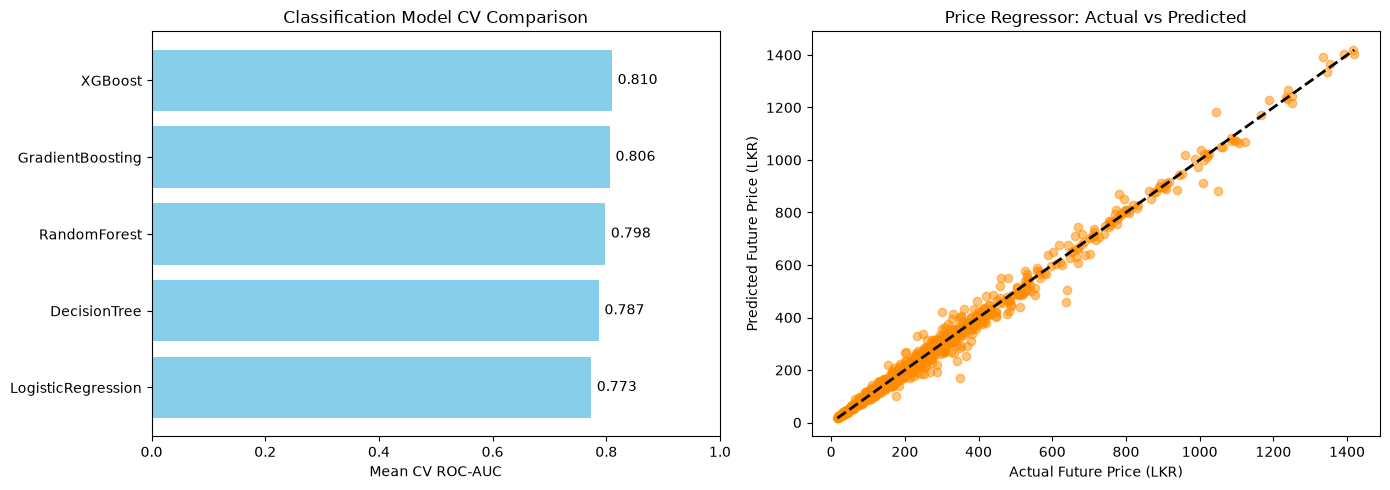

In [9]:
# =========================================================================
# STEP 8: EVALUATION VISUALIZATIONS (PLOT & SAVE)
# =========================================================================
print("\n=== Generating Metrics & Visualizations ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Classification CV Performance Comparison
model_names = list(cv_results.keys())
auc_scores = [cv_results[m]['auc'] for m in model_names]

axes[0].barh(model_names, auc_scores, color='skyblue')
axes[0].set_xlabel('Mean CV ROC-AUC')
axes[0].set_title('Classification Model CV Comparison')
axes[0].set_xlim(0, 1.0)
for i, v in enumerate(auc_scores):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va='center')

# Plot 2: Regression Actual vs Predicted Price
axes[1].scatter(y_test_reg, y_reg_pred, alpha=0.5, color='darkorange')
axes[1].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2)
axes[1].set_xlabel('Actual Future Price (LKR)')
axes[1].set_ylabel('Predicted Future Price (LKR)')
axes[1].set_title('Price Regressor: Actual vs Predicted')

plt.tight_layout()
plt.savefig('component2_model_performance.png')
print("📊 Performance chart saved as 'component2_model_performance.png'")